In [1]:
import pandas as pd
import numpy as np
print("Setup complete!")

Setup complete!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load all 50 stock CSV files
stocks_path = "../data/raw/stocks/"
all_files = [f for f in os.listdir(stocks_path) if f.endswith('.csv')]

# Remove the combined file, keep only individual stocks
all_files = [f for f in all_files if f != 'NIFTY50_all.csv' and f != 'stock_metadata.csv']

print(f"Total stock files found: {len(all_files)}")
print("Stocks:", [f.replace('.csv','') for f in sorted(all_files)])

Total stock files found: 50
Stocks: ['ADANIPORTS', 'ASIANPAINT', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJFINANCE', 'BHARTIARTL', 'BPCL', 'BRITANNIA', 'CIPLA', 'COALINDIA', 'DRREDDY', 'EICHERMOT', 'GAIL', 'GRASIM', 'HCLTECH', 'HDFC', 'HDFCBANK', 'HEROMOTOCO', 'HINDALCO', 'HINDUNILVR', 'ICICIBANK', 'INDUSINDBK', 'INFRATEL', 'INFY', 'IOC', 'ITC', 'JSWSTEEL', 'KOTAKBANK', 'LT', 'MARUTI', 'MM', 'NESTLEIND', 'NTPC', 'ONGC', 'POWERGRID', 'RELIANCE', 'SBIN', 'SHREECEM', 'SUNPHARMA', 'TATAMOTORS', 'TATASTEEL', 'TCS', 'TECHM', 'TITAN', 'ULTRACEMCO', 'UPL', 'VEDL', 'WIPRO', 'ZEEL']


In [4]:
# Load RELIANCE as sample
df = pd.read_csv(stocks_path + "RELIANCE.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (5306, 15)

Columns: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']

First 5 rows:


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [5]:
print("Date Range:", df['Date'].min(), "to", df['Date'].max())
print("\nBasic Statistics:")
df[['Open','High','Low','Close','Volume']].describe()

Date Range: 2000-01-03 00:00:00 to 2021-04-30 00:00:00

Basic Statistics:


,Open,High,Low,Close,Volume
count,5306.000000,5306.000000,5306.000000,5306.000000,5.306000e+03
mean,1012.602375,1026.823803,996.886977,1011.316839,5.583028e+06
std,572.575893,581.986757,560.703328,571.046753,4.983793e+06
min,205.500000,219.500000,197.150000,203.200000,5.282000e+04
25%,572.925000,582.950000,564.237500,572.512500,2.836454e+06
50%,939.000000,950.075000,927.550000,938.275000,4.213432e+06
75%,1247.675000,1267.350000,1227.450000,1248.275000,6.602604e+06
max,3298.000000,3298.000000,3141.300000,3220.850000,6.523089e+07


In [6]:
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
Date                     0
Symbol                   0
Series                   0
Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                2850
Deliverable Volume     514
%Deliverble            514
dtype: int64

Total missing: 3878


In [7]:
# Drop columns we don't need
df = df.drop(columns=['Trades', 'Deliverable Volume', '%Deliverble', 'Series', 'Last', 'VWAP'])

# Verify clean data
print("Cleaned columns:", df.columns.tolist())
print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nFinal shape: {df.shape}")
df.head()

Cleaned columns: ['Date', 'Symbol', 'Prev Close', 'Open', 'High', 'Low', 'Close', 'Volume', 'Turnover']
Missing values after cleaning:
Date          0
Symbol        0
Prev Close    0
Open          0
High          0
Low           0
Close         0
Volume        0
Turnover      0
dtype: int64

Final shape: (5306, 9)


,Date,Symbol,Prev Close,Open,High,Low,Close,Volume,Turnover
0,2000-01-03,RELIANCE,233.05,237.50,251.70,237.50,251.70,4456424,1.111319e+14
1,2000-01-04,RELIANCE,251.70,258.40,271.85,251.30,271.85,9487878,2.500222e+14
2,2000-01-05,RELIANCE,271.85,256.65,287.90,256.65,282.50,26833684,7.373697e+14
3,2000-01-06,RELIANCE,282.50,289.00,300.70,289.00,294.35,15682286,4.633254e+14
4,2000-01-07,RELIANCE,294.35,295.00,317.90,293.00,314.55,19870977,6.138388e+14


In [8]:
metadata = pd.read_csv(stocks_path + "stock_metadata.csv")
print("Sectors available:")
print(metadata['Industry'].value_counts())
metadata.head(10)

Sectors available:
Industry
FINANCIAL SERVICES          9
ENERGY                      7
AUTOMOBILE                  6
CONSUMER GOODS              6
METALS                      5
IT                          5
PHARMA                      3
CEMENT & CEMENT PRODUCTS    3
TELECOM                     2
SERVICES                    1
CONSTRUCTION                1
FERTILISERS & PESTICIDES    1
MEDIA & ENTERTAINMENT       1
Name: count, dtype: int64


,Company Name,Industry,Symbol,Series,ISIN Code
0,Adani Ports and Special Economic Zone Ltd.,SERVICES,ADANIPORTS,EQ,INE742F01042
1,Asian Paints Ltd.,CONSUMER GOODS,ASIANPAINT,EQ,INE021A01026
2,Axis Bank Ltd.,FINANCIAL SERVICES,AXISBANK,EQ,INE238A01034
3,Bajaj Auto Ltd.,AUTOMOBILE,BAJAJ-AUTO,EQ,INE917I01010
4,Bajaj Finserv Ltd.,FINANCIAL SERVICES,BAJAJFINSV,EQ,INE918I01018
5,Bajaj Finance Ltd.,FINANCIAL SERVICES,BAJFINANCE,EQ,INE296A01024
6,Bharti Airtel Ltd.,TELECOM,BHARTIARTL,EQ,INE397D01024
7,Bharat Petroleum Corporation Ltd.,ENERGY,BPCL,EQ,INE029A01011
8,Britannia Industries Ltd.,CONSUMER GOODS,BRITANNIA,EQ,INE216A01030
9,Cipla Ltd.,PHARMA,CIPLA,EQ,INE059A01026


In [9]:
dfs = []
for file in all_files:
    temp = pd.read_csv(stocks_path + file)
    dfs.append(temp)

all_stocks = pd.concat(dfs, ignore_index=True)
all_stocks['Date'] = pd.to_datetime(all_stocks['Date'])
all_stocks = all_stocks.sort_values(['Symbol','Date']).reset_index(drop=True)

print("Total records:", len(all_stocks))
print("Total stocks:", all_stocks['Symbol'].nunique())
print("Date range:", all_stocks['Date'].min(), "to", all_stocks['Date'].max())
all_stocks.head()

Total records: 235192
Total stocks: 65
Date range: 2000-01-03 00:00:00 to 2021-04-30 00:00:00


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2012-01-17,ADANIPORTS,EQ,135.5,137.1,141.00,135.00,140.1,140.00,138.13,1636196,2.260074e+13,18374.0,1004327.0,0.6138
1,2012-01-18,ADANIPORTS,EQ,140.0,142.0,143.80,138.70,143.0,141.70,141.25,890591,1.257986e+13,15615.0,404925.0,0.4547
2,2012-01-19,ADANIPORTS,EQ,141.7,144.0,150.55,143.15,149.5,149.40,146.72,1456077,2.136382e+13,31299.0,721545.0,0.4955
3,2012-01-20,ADANIPORTS,EQ,149.4,151.9,157.60,150.25,155.4,155.40,153.76,1634070,2.512583e+13,23335.0,861145.0,0.5270
4,2012-01-23,ADANIPORTS,EQ,155.4,155.4,155.40,145.10,146.4,146.75,149.54,1657609,2.478768e+13,12400.0,820653.0,0.4951


In [13]:
# Keep only EQ series (main series) and only NIFTY-50 stocks
metadata = pd.read_csv(stocks_path + "stock_metadata.csv")
nifty50_symbols = metadata['Symbol'].tolist()

all_stocks = all_stocks[
    (all_stocks['Symbol'].isin(nifty50_symbols)) & 
    (all_stocks['Series'] == 'EQ')
].reset_index(drop=True)

print("After filtering:")
print(f"Total records: {len(all_stocks)}")
print(f"Total stocks: {all_stocks['Symbol'].nunique()}")
print(f"Stocks: {sorted(all_stocks['Symbol'].unique().tolist())}")

After filtering:
Total records: 207850
Total stocks: 49
Stocks: ['ADANIPORTS', 'ASIANPAINT', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJFINANCE', 'BHARTIARTL', 'BPCL', 'BRITANNIA', 'CIPLA', 'COALINDIA', 'DRREDDY', 'EICHERMOT', 'GAIL', 'GRASIM', 'HCLTECH', 'HDFC', 'HDFCBANK', 'HEROMOTOCO', 'HINDALCO', 'HINDUNILVR', 'ICICIBANK', 'INDUSINDBK', 'INFY', 'IOC', 'ITC', 'JSWSTEEL', 'KOTAKBANK', 'LT', 'M&M', 'MARUTI', 'NESTLEIND', 'NTPC', 'ONGC', 'POWERGRID', 'RELIANCE', 'SBIN', 'SHREECEM', 'SUNPHARMA', 'TATAMOTORS', 'TATASTEEL', 'TCS', 'TECHM', 'TITAN', 'ULTRACEMCO', 'UPL', 'VEDL', 'WIPRO', 'ZEEL']


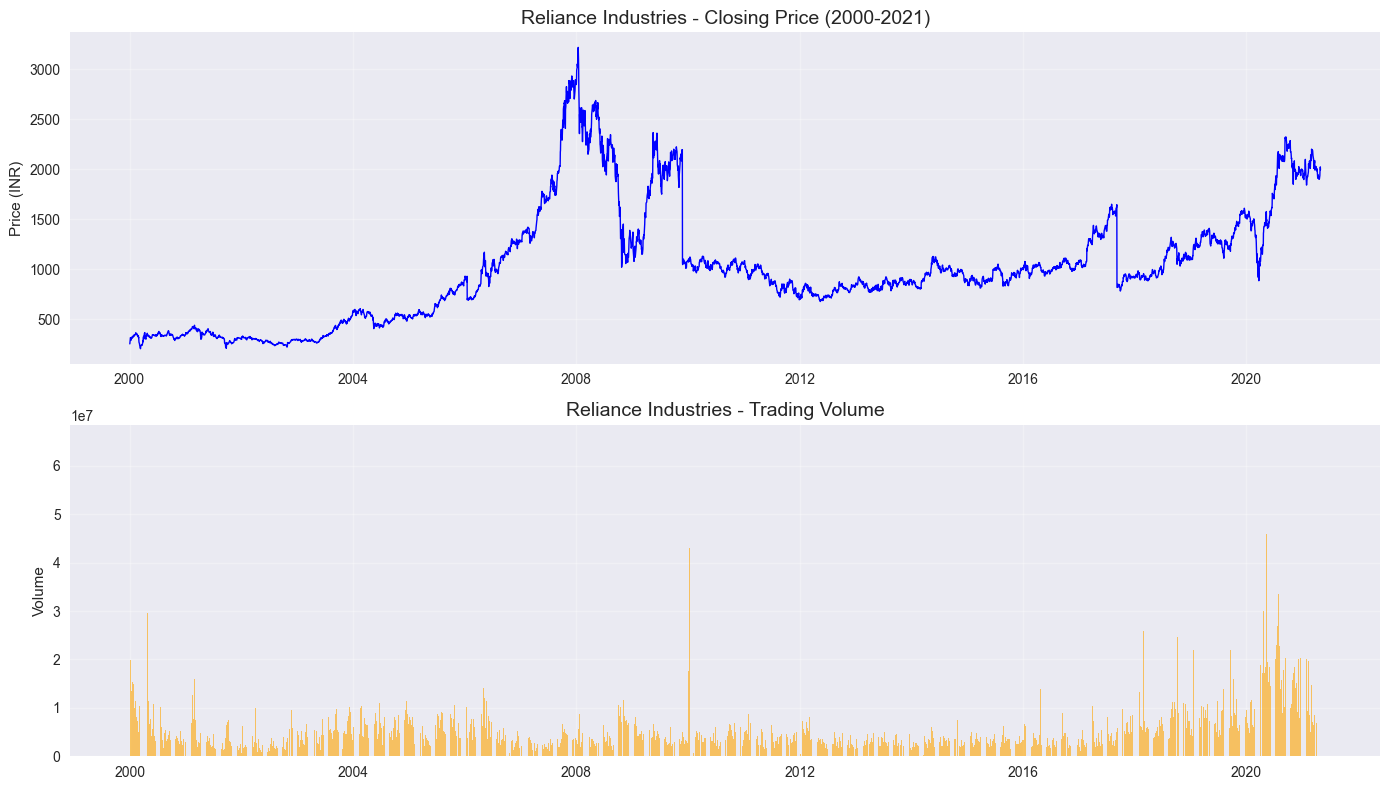

Chart saved!


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Close price
axes[0].plot(df['Date'], df['Close'], color='blue', linewidth=1)
axes[0].set_title('Reliance Industries - Closing Price (2000-2021)', fontsize=14)
axes[0].set_ylabel('Price (INR)')
axes[0].grid(True, alpha=0.3)

# Volume
axes[1].bar(df['Date'], df['Volume'], color='orange', alpha=0.6, width=1)
axes[1].set_title('Reliance Industries - Trading Volume', fontsize=14)
axes[1].set_ylabel('Volume')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/reliance_price_volume.png', dpi=150)
plt.show()
print("Chart saved!")

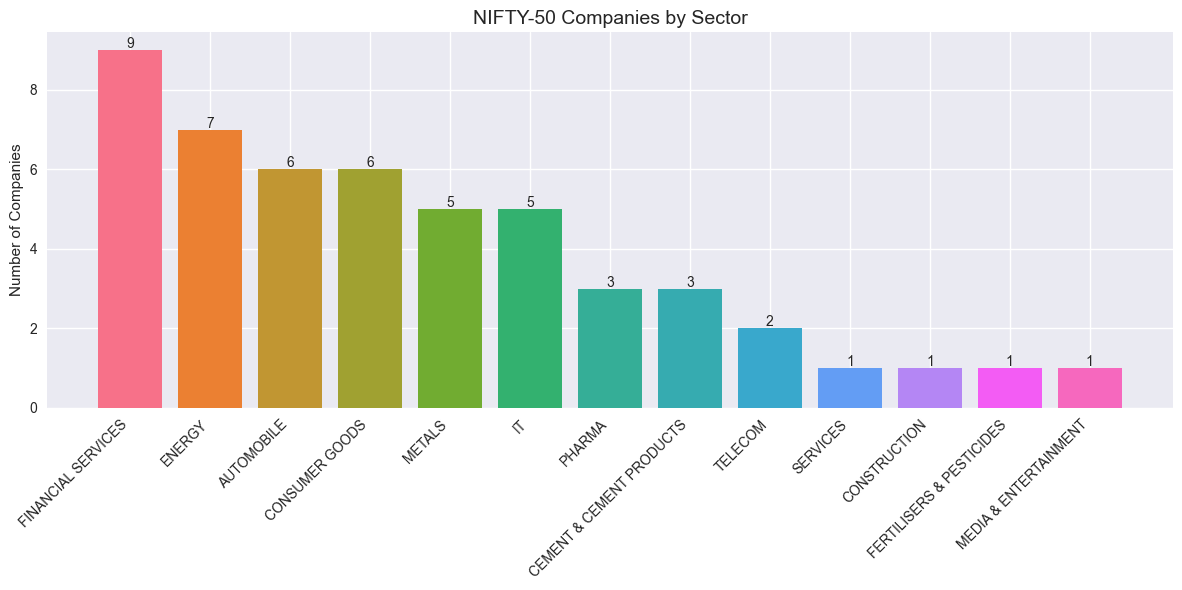

In [15]:
plt.figure(figsize=(12, 6))
sector_counts = metadata['Industry'].value_counts()
colors = sns.color_palette('husl', len(sector_counts))
bars = plt.bar(sector_counts.index, sector_counts.values, color=colors)
plt.title('NIFTY-50 Companies by Sector', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Companies')
for bar, val in zip(bars, sector_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/sector_distribution.png', dpi=150)
plt.show()

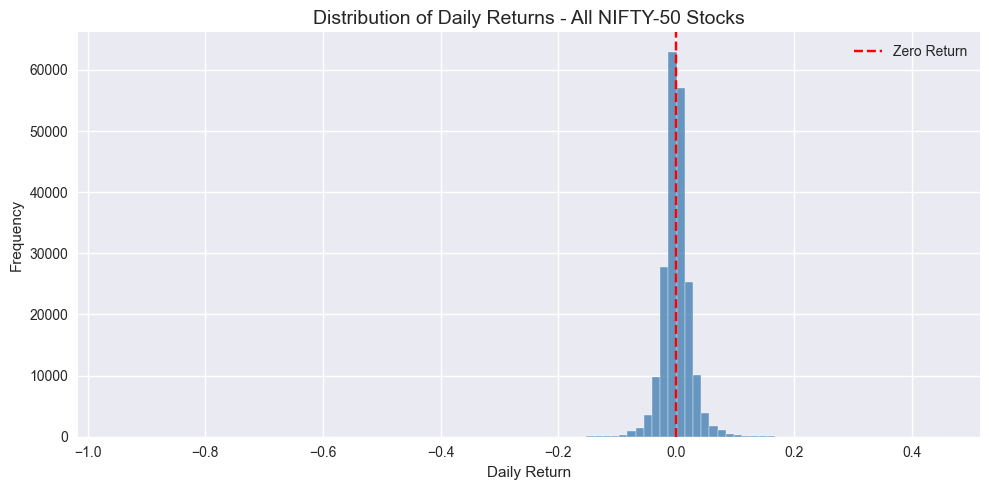

Average Daily Return: 0.0007
Std Dev of Returns: 0.0263


In [16]:
# Calculate daily returns for all stocks
all_stocks['Daily_Return'] = all_stocks.groupby('Symbol')['Close'].pct_change()

plt.figure(figsize=(10, 5))
all_stocks['Daily_Return'].dropna().hist(bins=100, color='steelblue', 
                                          edgecolor='white', alpha=0.8)
plt.title('Distribution of Daily Returns - All NIFTY-50 Stocks', fontsize=14)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(0, color='red', linestyle='--', label='Zero Return')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/returns_distribution.png', dpi=150)
plt.show()

print(f"Average Daily Return: {all_stocks['Daily_Return'].mean():.4f}")
print(f"Std Dev of Returns: {all_stocks['Daily_Return'].std():.4f}")

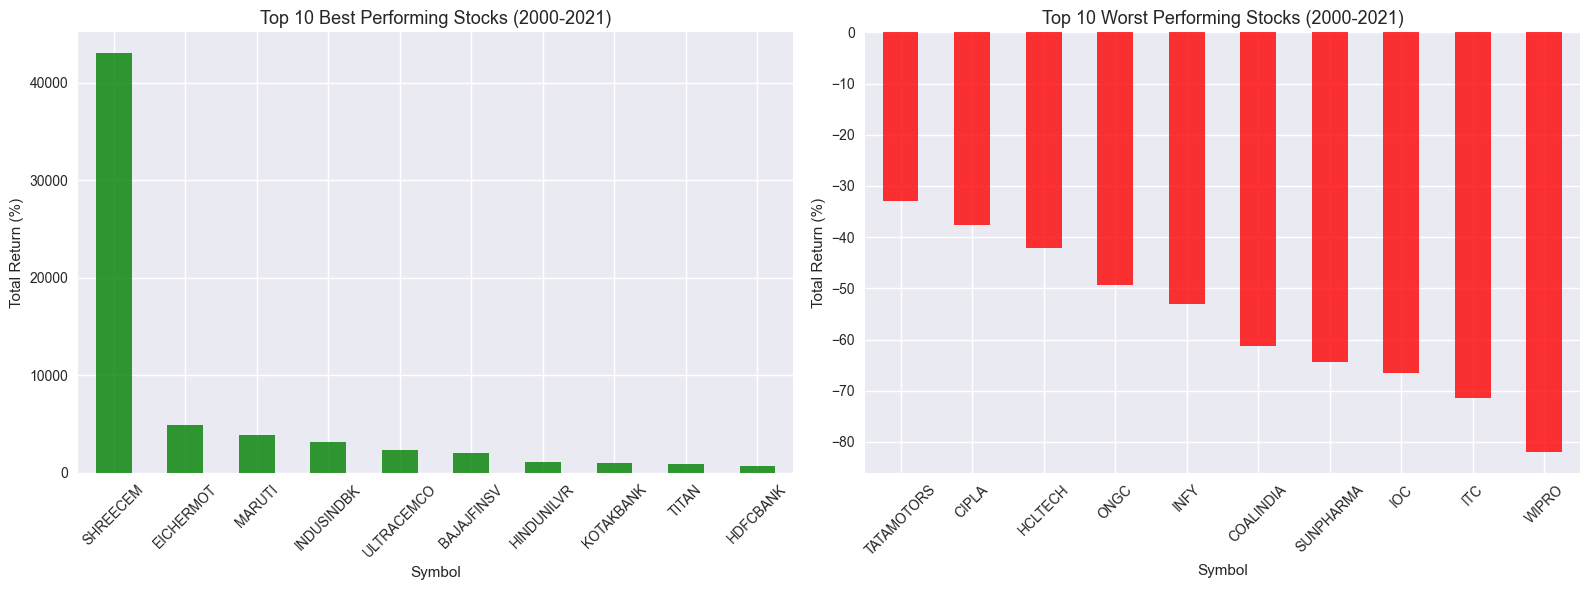

Best performer: SHREECEM (43005%)
Worst performer: WIPRO (-82%)


In [17]:
# Calculate total return for each stock
stock_returns = all_stocks.groupby('Symbol').apply(
    lambda x: (x.sort_values('Date')['Close'].iloc[-1] / 
               x.sort_values('Date')['Close'].iloc[0] - 1) * 100
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 best
stock_returns.head(10).plot(kind='bar', ax=axes[0], color='green', alpha=0.8)
axes[0].set_title('Top 10 Best Performing Stocks (2000-2021)', fontsize=13)
axes[0].set_ylabel('Total Return (%)')
axes[0].tick_params(axis='x', rotation=45)

# Top 10 worst
stock_returns.tail(10).plot(kind='bar', ax=axes[1], color='red', alpha=0.8)
axes[1].set_title('Top 10 Worst Performing Stocks (2000-2021)', fontsize=13)
axes[1].set_ylabel('Total Return (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/best_worst_stocks.png', dpi=150)
plt.show()

print("Best performer:", stock_returns.index[0], f"({stock_returns.iloc[0]:.0f}%)")
print("Worst performer:", stock_returns.index[-1], f"({stock_returns.iloc[-1]:.0f}%)")

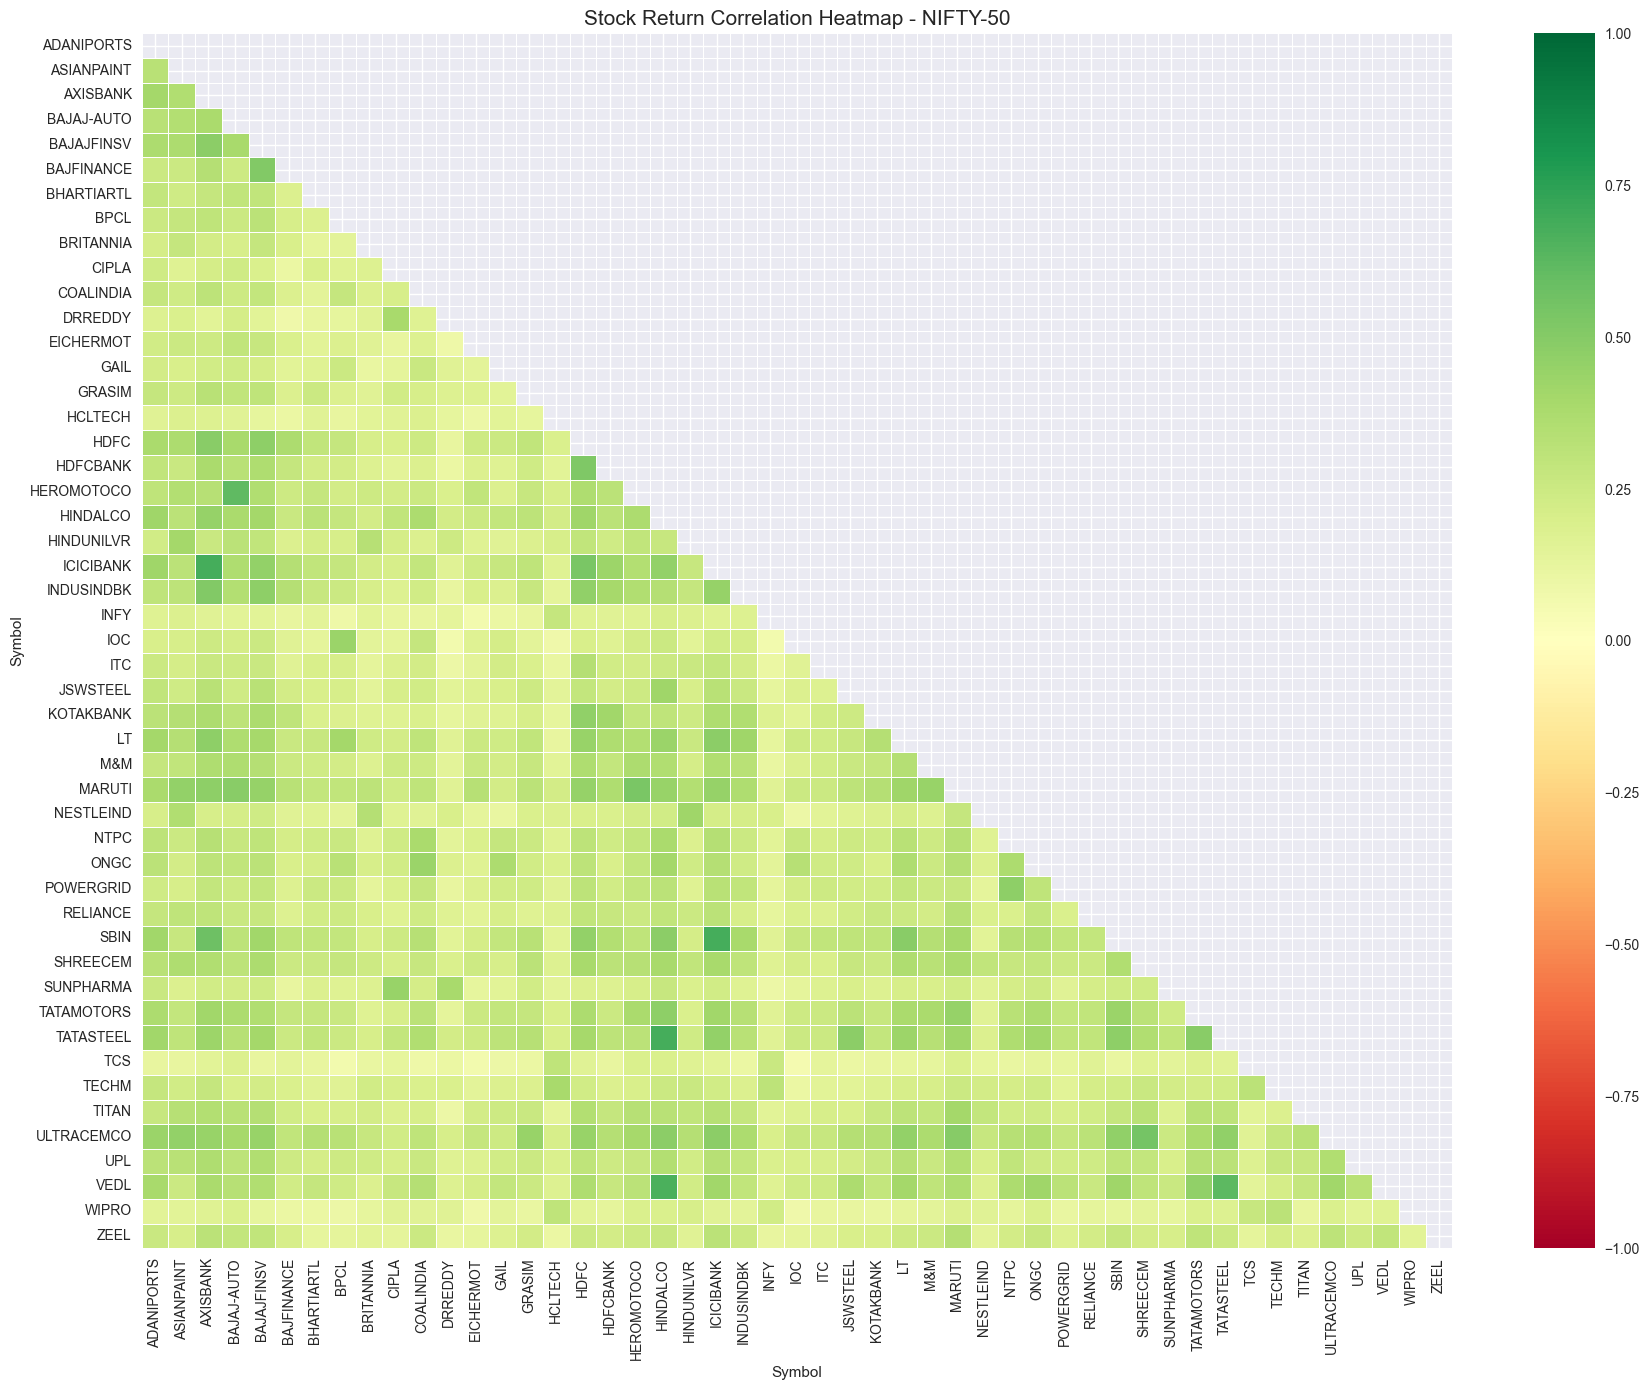

In [18]:
# Pivot close prices
close_prices = all_stocks.pivot_table(
    index='Date', columns='Symbol', values='Close'
)

# Calculate correlation
returns_pivot = close_prices.pct_change().dropna()
corr_matrix = returns_pivot.corr()

plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=False, 
            cmap='RdYlGn', 
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Stock Return Correlation Heatmap - NIFTY-50', fontsize=15)
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150)
plt.show()

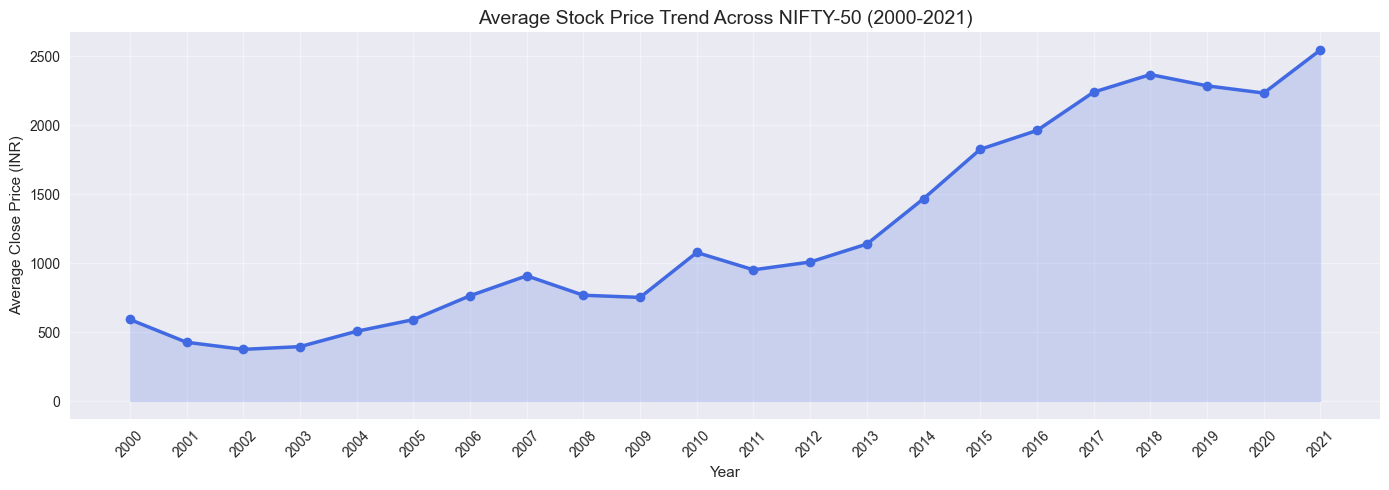

Key Observations:
Lowest avg price year: 2002 (376 INR)
Highest avg price year: 2021 (2545 INR)
Overall growth: 329%


In [19]:
# Average yearly close price across all stocks
all_stocks['Year'] = all_stocks['Date'].dt.year
yearly_avg = all_stocks.groupby('Year')['Close'].mean()

plt.figure(figsize=(14, 5))
plt.plot(yearly_avg.index, yearly_avg.values, 
         marker='o', linewidth=2.5, color='royalblue', markersize=7)
plt.fill_between(yearly_avg.index, yearly_avg.values, alpha=0.2, color='royalblue')
plt.title('Average Stock Price Trend Across NIFTY-50 (2000-2021)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Close Price (INR)')
plt.xticks(yearly_avg.index, rotation=45)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('../data/processed/yearly_trend.png', dpi=150)
plt.show()

# Key observations
print("Key Observations:")
print(f"Lowest avg price year: {yearly_avg.idxmin()} ({yearly_avg.min():.0f} INR)")
print(f"Highest avg price year: {yearly_avg.idxmax()} ({yearly_avg.max():.0f} INR)")
print(f"Overall growth: {((yearly_avg.iloc[-1]/yearly_avg.iloc[0])-1)*100:.0f}%")